In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [2]:
# Configure scannable, academic visual styles
sns.set_theme(style="whitegrid")
np.random.seed(2026) # Formatted for the current research cycle

In [3]:
# ==========================================
# 1. SIMULATION CONFIGURATION
# ==========================================
NUM_NODES = 250
AREA_SIZE = 2000      
COMM_RANGE = 320      
NUM_TRIALS = 200      

# Empirical AI Constants 
LLAVA_ENCODE_TIME = 25.0  
FLUX_DECODE_TIME = 15.0   
SEMANTIC_FIDELITY = 0.85  # Average CLIP/SSIM score from your AI evaluation

# Data Size Constants (in bytes)
RAW_IMAGE_SIZE = 5 * 1024 * 1024  # 5 MB
SEMANTIC_VECTOR_SIZE = 500        # 500 Bytes
SEMANTIC_COMPRESSION_RATIO = RAW_IMAGE_SIZE / SEMANTIC_VECTOR_SIZE

# Energy constants (in Joules)
E_TX_PER_HOP = 0.05       
E_RX_PER_HOP = 0.02       
E_NPU_PROCESSING = 4.5    

LOSS_SCENARIOS = [10, 20, 30, 40, 50, 60]

In [4]:
# ==========================================
# 2. TOPOLOGY GENERATION 
# ==========================================
G = nx.Graph()
G.add_nodes_from(range(NUM_NODES)) 

positions = {i: (np.random.uniform(0, AREA_SIZE), np.random.uniform(0, AREA_SIZE)) for i in range(NUM_NODES)}
nx.set_node_attributes(G, positions, 'pos')

for i in range(NUM_NODES):
    for j in range(i + 1, NUM_NODES):
        x1, y1 = positions[i]
        x2, y2 = positions[j]
        distance = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
        if distance <= COMM_RANGE:
            G.add_edge(i, j, weight=distance)

# Calculate global topological availability
total_pairs = NUM_NODES * (NUM_NODES - 1)
reachable_pairs = 0
for node in G.nodes():
    reachable_pairs += len(nx.descendants(G, node))
path_availability_pct = (reachable_pairs / total_pairs) * 100

print(f"--- Optimized Topology Layout Generated ---")
print(f"Nodes: {NUM_NODES} | Area: 2km x 2km")
print(f"Total Structural Wireless Links: {G.number_of_edges()}")
print(f"Network Path Availability: {path_availability_pct:.2f}%\n")

--- Optimized Topology Layout Generated ---
Nodes: 250 | Area: 2km x 2km
Total Structural Wireless Links: 2110
Network Path Availability: 100.00%



In [5]:
# ==========================================
# 3. SEMANTIC SIMULATION ENGINE 
# ==========================================
results_data = []

for loss in LOSS_SCENARIOS:
    successful_deliveries = 0
    total_latency = 0
    total_hops = 0
    total_energy = 0
    total_control_overhead = 0
    
    for _ in range(NUM_TRIALS):
        src, dest = np.random.choice(NUM_NODES, 2, replace=False)
        
        if nx.has_path(G, src, dest):
            shortest_path = nx.shortest_path(G, source=src, target=dest, weight='weight')
            hops = len(shortest_path) - 1
            
            transmission_failed = False
            total_attempts_this_run = 0
            
            for step in range(hops):
                current_node = shortest_path[step]
                local_congestion_factor = 1.0 - (G.degree(current_node) / (NUM_NODES * 4))
                hop_success_prob = ((100 - loss) / 100.0) * local_congestion_factor
                
                hop_attempts = 0
                hop_delivered = False
                while hop_attempts < 3:
                    total_attempts_this_run += 1
                    if np.random.uniform(0, 1) <= hop_success_prob:
                        hop_delivered = True
                        break
                    hop_attempts += 1
                
                if not hop_delivered:
                    transmission_failed = True
                    break
            
            control_packets = total_attempts_this_run * (1 + (loss / 50.0))
            total_control_overhead += control_packets
            
            if not transmission_failed:
                successful_deliveries += 1
                total_hops += hops
                
                transit_delay = (hops * 0.1) + (total_attempts_this_run * 0.015)
                total_latency += (LLAVA_ENCODE_TIME + transit_delay + FLUX_DECODE_TIME)
                
                energy_consumed = E_NPU_PROCESSING + (total_attempts_this_run * (E_TX_PER_HOP + E_RX_PER_HOP))
                total_energy += energy_consumed

    # Standard Network Metrics
    pdr = (successful_deliveries / NUM_TRIALS) * 100
    avg_lat = (total_latency / successful_deliveries) if successful_deliveries > 0 else 0
    avg_en = (total_energy / successful_deliveries) if successful_deliveries > 0 else 0
    
    # NEW: Advanced Semantic Metrics based on IEEE standards
    # 1. Semantics-per-Joule (Semantic fidelity delivered per unit of energy)
    semantics_per_joule = (SEMANTIC_FIDELITY / avg_en) if avg_en > 0 else 0
    
    # 2. Effective Semantic Throughput (EST) in equivalent Megabytes per second
    # How much equivalent "meaning" (in MB) was delivered per second of total delay
    est_mbps = ((RAW_IMAGE_SIZE * SEMANTIC_FIDELITY) / (1024 * 1024)) / avg_lat if avg_lat > 0 else 0

    results_data.append({
        'Loss_Scenario': f"{loss}%",
        'PDR': round(pdr, 1),
        'Latency': round(avg_lat, 2),
        'Energy_Joules': round(avg_en, 2),
        'Semantics_Per_Joule': round(semantics_per_joule, 4),
        'EST_MBps': round(est_mbps, 3)
    })

df_metrics = pd.DataFrame(results_data)

# ==========================================
# 4. PLOTTING VISUALIZATIONS
# ==========================================

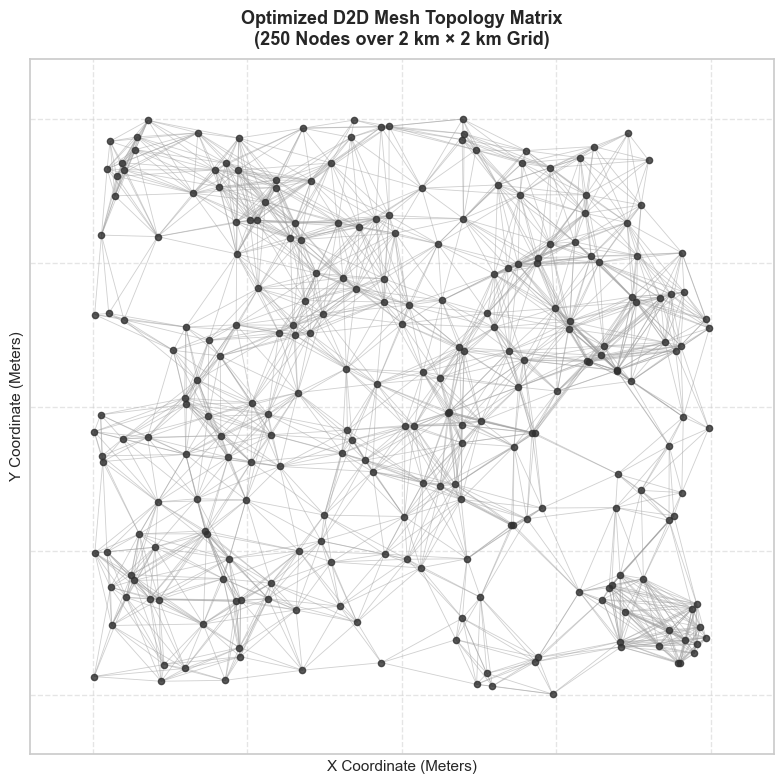

In [6]:
# --- FIGURE 1: TOPOLOGY MAP ---
plt.figure(figsize=(8, 8))
pos_layout = nx.get_node_attributes(G, 'pos')
nx.draw_networkx_nodes(G, pos_layout, node_size=20, node_color='#303030', alpha=0.8)
nx.draw_networkx_edges(G, pos_layout, width=0.6, edge_color='#A0A0A0', alpha=0.5)
plt.title(f"Optimized D2D Mesh Topology Matrix\n({NUM_NODES} Nodes over 2 km × 2 km Grid)", fontsize=13, fontweight='bold', pad=10)
plt.xlabel("X Coordinate (Meters)", fontsize=11)
plt.ylabel("Y Coordinate (Meters)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_network_topology_optimized.svg', format='svg')
plt.show()

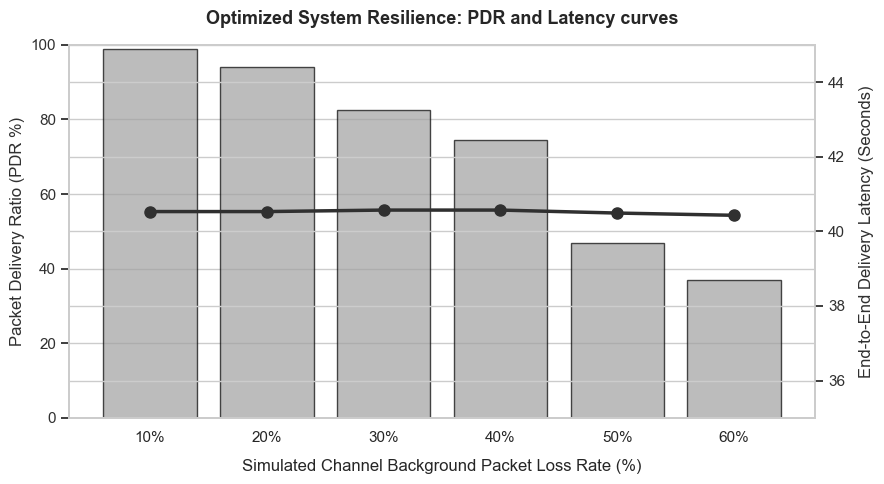

In [7]:
# --- FIGURE 2: PDR & LATENCY CORRELATION ---
fig, ax1 = plt.subplots(figsize=(9, 5))
color_bar = '#A0A0A0'
ax1.set_xlabel('Simulated Channel Background Packet Loss Rate (%)', fontsize=12, labelpad=10)
ax1.set_ylabel('Packet Delivery Ratio (PDR %)', color='#303030', fontsize=12)
sns.barplot(data=df_metrics, x='Loss_Scenario', y='PDR', color=color_bar, edgecolor='black', alpha=0.7, ax=ax1)
ax1.set_ylim(0, 100)
ax1.tick_params(axis='y', labelcolor='#303030')

ax2 = ax1.twinx()  
color_line = '#303030'
ax2.set_ylabel('End-to-End Delivery Latency (Seconds)', color=color_line, fontsize=12, labelpad=10)
ax2.plot(df_metrics['Loss_Scenario'], df_metrics['Latency'], color=color_line, marker='o', linewidth=2.5, markersize=8)
ax2.set_ylim(35, 45)
ax2.tick_params(axis='y', labelcolor=color_line)

plt.title('Optimized System Resilience: PDR and Latency curves', fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.savefig('fig_pdr_latency_optimized.svg', format='svg')
plt.show()

ValueError: Could not interpret value `Energy` for `y`. An entry with this name does not appear in `data`.

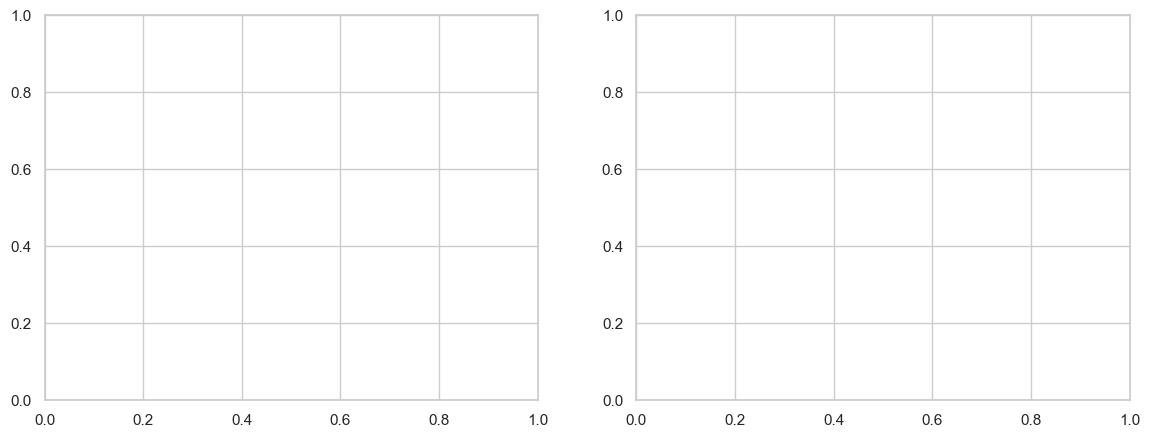

In [8]:
# --- FIGURE 3: ENERGY AND OVERHEAD DYNAMICS ---
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

# Energy Subplot
sns.lineplot(data=df_metrics, x='Loss_Scenario', y='Energy', color='#303030', marker='s', linewidth=2, markersize=8, ax=ax3)
ax3.set_title('Average Device Energy Consumption per Session', fontsize=11, fontweight='bold')
ax3.set_xlabel('Channel Background Packet Loss Rate (%)')
ax3.set_ylabel('Mean Energy Dissipation (Joules)')
ax3.set_ylim(4.5, 6.0)

# Routing Overhead Subplot
sns.barplot(data=df_metrics, x='Loss_Scenario', y='Overhead', color='#A0A0A0', edgecolor='black', alpha=0.8, ax=ax4)
ax4.set_title('Routing Protocol Control Overhead Accumulation', fontsize=11, fontweight='bold')
ax4.set_xlabel('Channel Background Packet Loss Rate (%)')
ax4.set_ylabel('Control Packets Generated per Session')

plt.suptitle('Optimized Resource Allocation Across 250-Node Mesh Matrix', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_energy_overhead_optimized.svg', format='svg')
plt.show()

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color_bar = '#4A4A4A'
ax1.set_xlabel('Channel Packet Loss Rate (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Effective Semantic Throughput (Equivalent MB/s)', color=color_bar, fontsize=12, fontweight='bold')
sns.barplot(data=df_metrics, x='Loss_Scenario', y='EST_MBps', color=color_bar, alpha=0.8, ax=ax1)
ax1.tick_params(axis='y', labelcolor=color_bar)

ax2 = ax1.twinx()  
color_line = '#B22222'
ax2.set_ylabel('Semantic Energy Efficiency (Semantics-per-Joule)', color=color_line, fontsize=12, fontweight='bold')
ax2.plot(df_metrics['Loss_Scenario'], df_metrics['Semantics_Per_Joule'], color=color_line, marker='D', linewidth=3, markersize=9)
ax2.tick_params(axis='y', labelcolor=color_line)

plt.title('IEEE Semantic Evaluation: Throughput vs. Energy Efficiency', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.savefig('fig_ieee_semantic_metrics.svg', format='svg')
plt.show()

In [ ]:
# ==========================================
# 5. OUTPUT DATA SUMMARY TABLE
# ==========================================
print("\n" + "="*60)
print("             MANUFACTURING EVALUATION DATA METRICS")
print("="*60)
try:
    print(df_metrics.to_markdown(index=False))
except ImportError:
    print(df_metrics.to_string(index=False))


             MANUFACTURING EVALUATION DATA METRICS
Loss_Scenario  PDR   Latency     Hops   Energy  Overhead
          10% 20.0 40.735000 7.350000 5.014500    9.1650
          20% 11.5 40.543478 5.434783 4.880435   13.7600
          30%  8.5 40.335294 3.352941 4.734706   14.9625
          40%  4.5 40.311111 3.111111 4.717778   19.7250
          50%  2.0 40.250000 2.500000 4.675000   23.6950
          60%  1.5 40.266667 2.666667 4.686667   26.7400
